# use case- predicting cofee cooling time based on cup size & room temperature
# objective-
to predict how long(in minutes) it will take for a hot coffee to cool down to drinkable temperature based on
Initial Temperature of the room
size of the coffeee cup

# Goal 
build a linear regression model that helps cafes/restro estimating serving time(e.g., avoid serving coffee that's too hot or too cold).


workflow
create a synthetic data 
EDA
train Linear Regression
coefficients and visualization
insights

In [25]:
# predicting coffee cooling time based on Room temp & Cup size

# Step 1 Import Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [26]:
# step2 -- create synthetic dataset
#features:
# roomtemp - room temperature
# cup_size(ml)-- volume of the cofee cup
# Target
# cooling_time 9min) --- time for hot cofee to reach 60 c

np.random.seed(42)

room_temp = np.random.randint(15, 30, 100)
cup_size = np.random.randint(150, 500, 100)

cooling_time = (0.5 * cup_size/100) - (0.2* room_temp) + np.random.normal(0,2,100)

# Build a dataframe
df = pd.DataFrame({
    'room_temp': room_temp,
    'cup_size' : cup_size,
    'cooling_time' : cooling_time
})
print("sample Data:\n", df.head())

sample Data:
    room_temp  cup_size  cooling_time
0         21       311     -0.945158
1         18       351     -4.467648
2         27       419     -5.045610
3         29       453     -4.548286
4         25       420     -5.519901


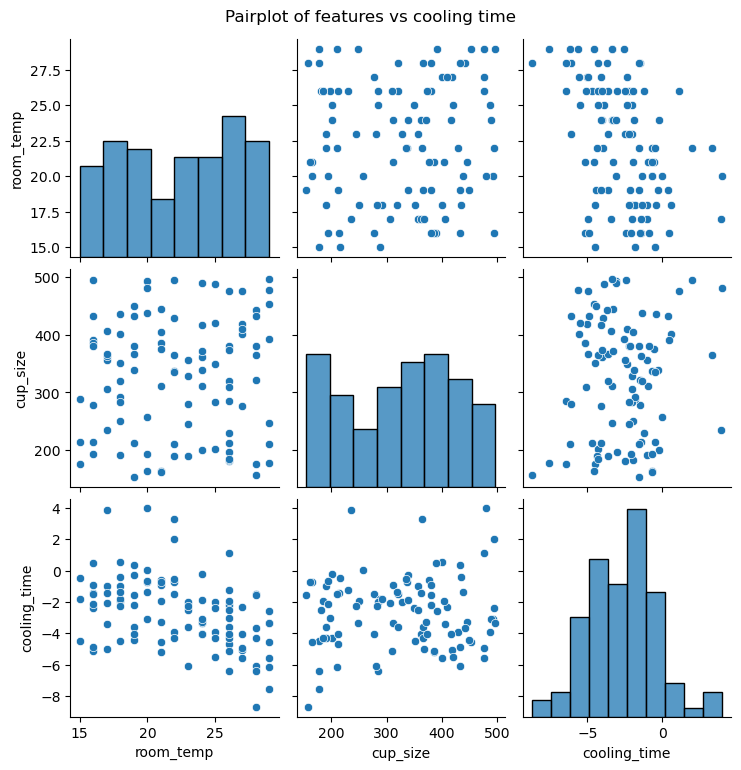

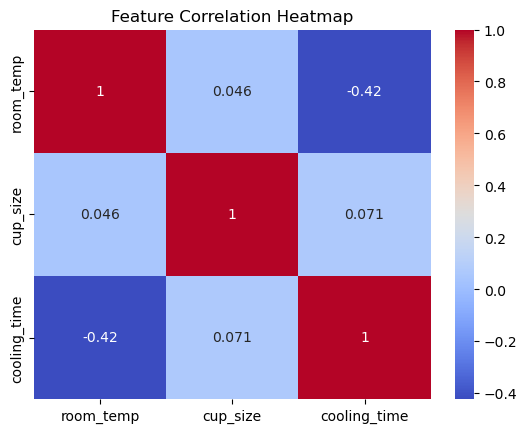

In [27]:
# 3. eda
# pairplot to see relationship between variables
sns.pairplot(df)
plt.suptitle("Pairplot of features vs cooling time", y=1.02)
plt.show()

# correlation heatmap to check feature- target relationship
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [28]:
# 4. split data
X= df[["room_temp","cup_size"]]
y = df[["cooling_time"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)


In [29]:
# 5 train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("---Model Details---")
print("Coefficient (effect of each feature):", model.coef_)
print("Intersept (Base Value):", model.intercept_)


---Model Details---
Coefficient (effect of each feature): [[-0.21415413  0.00254722]]
Intersept (Base Value): [1.27379506]


sample Data:
    room_temp  cup_size  cooling_time
0         21       311     -0.945158
1         18       351     -4.467648
2         27       419     -5.045610
3         29       453     -4.548286
4         25       420     -5.519901
---Model Details---


Text(0.5, 1.0, 'Actual vs Predicted Cooling Time')

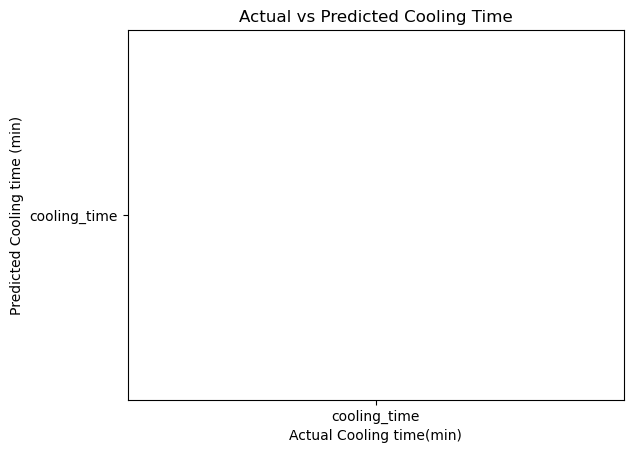

In [4]:
# 6. make prediction
# predicting coffee cooling time based on Room temp & Cup size

# Step 1 Import Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


np.random.seed(42)

room_temp = np.random.randint(15, 30, 100)
cup_size = np.random.randint(150, 500, 100)

cooling_time = (0.5 * cup_size/100) - (0.2* room_temp) + np.random.normal(0,2,100)

# Build a dataframe
df = pd.DataFrame({
    'room_temp': room_temp,
    'cup_size' : cup_size,
    'cooling_time' : cooling_time
})
print("sample Data:\n", df.head())
X= df[["room_temp","cup_size"]]
y = df[["cooling_time"]]


model = LinearRegression()
model.fit(X_train, y_train)

print("---Model Details---")
# print("Coefficient (effect of each feature):", model.coef_)
# print("Intersept (Base Value):", model.intercept_)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)
y_pred = model.predict(X_test)
# print([min(y_test),max(y_test)])
# print(y_test)
# Compare actual vs predicted visually
plt.scatter(y_test, y_pred, color="blue")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)], color="red", linestyle="--")
plt.xlabel("Actual Cooling time(min)")
plt.ylabel("Predicted Cooling time (min)")
plt.title("Actual vs Predicted Cooling Time")
# plt.show()

---Model Details---
Coefficient (effect of each feature): [-0.21415413  0.00254722]
Intercept (Base Value): 1.2737950610750062


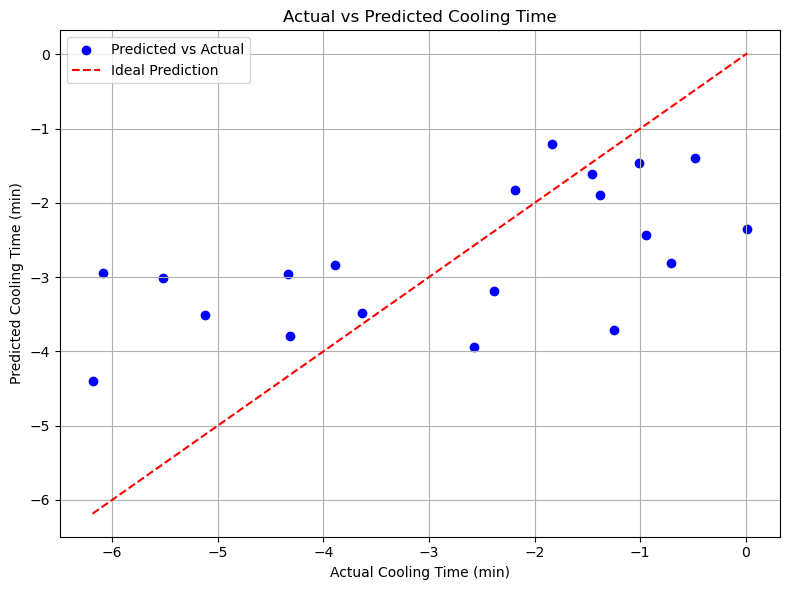

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Seed for reproducibility
np.random.seed(42)

# Simulated Data
room_temp = np.random.randint(15, 30, 100)
cup_size = np.random.randint(150, 500, 100)
cooling_time = (0.5 * cup_size / 100) - (0.2 * room_temp) + np.random.normal(0, 2, 100)

# Build DataFrame
df = pd.DataFrame({
    'room_temp': room_temp,
    'cup_size': cup_size,
    'cooling_time': cooling_time
})

# Features and target
X = df[['room_temp', 'cup_size']]
y = df['cooling_time']  # Use Series instead of DataFrame here for simplicity

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model details
print("---Model Details---")
print("Coefficient (effect of each feature):", model.coef_)
print("Intercept (Base Value):", model.intercept_)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Ideal Prediction")
plt.xlabel("Actual Cooling Time (min)")
plt.ylabel("Predicted Cooling Time (min)")
plt.title("Actual vs Predicted Cooling Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
